In [1]:
"""
Solution for week 9 project in Data Visualization

Creating images with point overlays using numpy and matplotlib
"""

import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
# Provided code - define radial function for creating interesting images
EPS = 20

def radial(centers, weights, point):
    """
    Input: List centers of tuples corresponding to center of radial functions, 
    tuple point
    
    Output: Float corresponding to value of radial basis function via
    https://en.wikipedia.org/wiki/Radial_basis_function
    """
    
    val = 0 
    for center, weight in zip(centers, weights):
        rad = math.sqrt((center[0]-point[0]) ** 2 + (center[1] - point[1]) ** 2)
        val += weight * math.exp(- EPS * (rad ** 2))
    return val

In [3]:
# Extract DPI (72) from matplotlib for Jupyter notebook
DPI = round(mpl.rcParams['figure.dpi'])

In [4]:
# Define function to create image of weighted sum of radial basis functions

def make_radial_image(centers, weights, fig_size):
    """
    Input: List centers of tuples corresponding to center of radial functions, 
    list weights of floats corresponding to weight of each radial function,
    tuple fig_size corresponding to size of output figure in inches
    
    Output:  numpy array corresponding to image of specified size
    computed using the function radial on the unit square [0, 1]^2
    
    Note that figure sizes that are not square involve non-uniform scaling
    """
    
    # Compute the size of the desired image using fig_size and DPI
    x_pixels = fig_size[0] * DPI
    y_pixels = fig_size[1] * DPI    
    
    # Generate grid over [0,1]^2 consistent with the desired image size
    x_vals = np.linspace(0, 1, x_pixels + 1)
    y_vals = np.linspace(0, 1, y_pixels + 1)
    x_grid, y_grid = np.meshgrid(x_vals, y_vals)
    grid = np.transpose(np.array([x_grid, y_grid]), (1, 2, 0))
    flat_grid = grid.reshape(len(x_vals) * len(y_vals), 2)

    # Evaluate radial() at each point in the grid using provided centers and weights
    flat_image = np.array([radial(centers, weights, point) for point in flat_grid])
    image = flat_image.reshape(len(y_vals), len(x_vals))
    
    return image

In [5]:
def test_make_radial_image():
    """ Test make_radial_image """
    
    centers = [(0.25, 0.25), (0.25, 0.75), (0.75, 0.5)]
    weights = [10.0, 20.0, 30.0]
    
    radial_image = make_radial_image(centers, weights, (2, 2))
    print(radial_image.shape)
    
    radial_image = make_radial_image(centers, weights, (5, 5))
    print(radial_image.shape)
    
    radial_image = make_radial_image(centers, weights, (6, 4))
    print(radial_image.shape)
    
test_make_radial_image()

# Note that shape of numpy array radial_image is (height x width)

(201, 201)
(501, 501)
(401, 601)


In [6]:
# Plot radial image and appropriate scaled centers

def plot_image_overlay(centers, weights, fig_size, output_file):
    """
    Input: List centers of tuples corresponding to center of radial functions, 
    list weights of floats corresponding to weight of each radial function,
    tuple fig_size corresponding to size of output figure in inches
    
    Output:  matplotlib figure consisting of plot of radial functions 
    with specified centers and weights on the unit square [0, 1]^2 
    with specified size fig_size in inches
    
    Note that figure sizes that are not square involve non-uniform scaling
    """
    
    # Compute the size of the desired image using fig_size and DPI
    x_pixels = fig_size[0] * DPI
    y_pixels = fig_size[1] * DPI    
    
    # Compute array using make_radial_image()
    radial_image = make_radial_image(centers, weights, fig_size)
    
    # Scale centers to overlay onto the plot of radial_image
    scaled_xcenters = [x_pixels * x_coord
                       for (x_coord, y_coord) in centers]
    scaled_ycenters = [y_pixels * y_coord
                       for (x_coord, y_coord) in centers]
    
    # Set marker size to be proportional to weigths, scale appropriately by fig_size
    marker_size = [(fig_size[0] * fig_size[1]) * weight for weight in weights]
    
    # Draw the array as an image using plt.imshow() - no axes
    fig, axs = plt.subplots(figsize=fig_size)
    axs.imshow(radial_image, origin="lower")
    
    # Turn off axes and set zero margins using plt.subplots_adjust()
    axs.set_axis_off()
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # Overlay scaled centers with marker size appropriately adjust by fig_size
    axs.scatter(x=scaled_xcenters, y=scaled_ycenters, c="red", s=marker_size)
    fig.savefig(output_file)
    return fig
    

Expect shape of saved image is 200 by 200
Saved image has shape 200 by 200
Expect shape of saved image is 500 by 500
Saved image has shape 500 by 500
Expect shape of saved image is 600 by 400
Saved image has shape 600 by 400


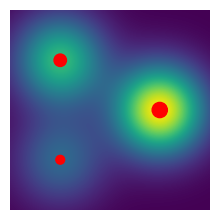

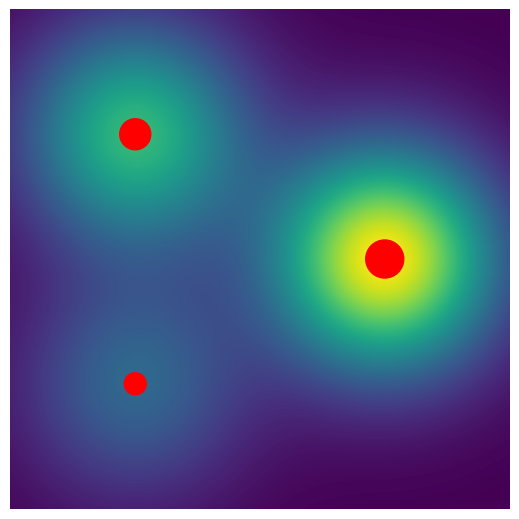

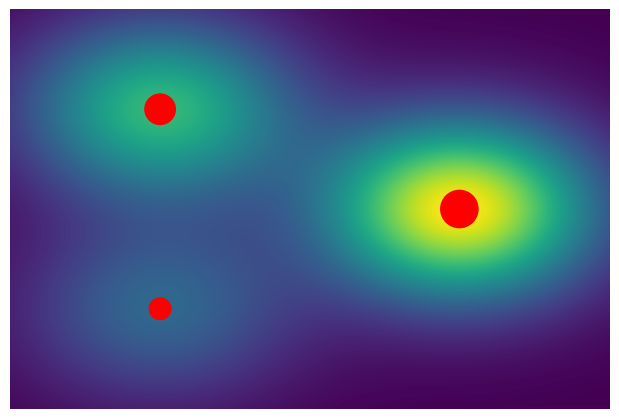

In [7]:
def test_plot_image_overlay():
    """ Test make_radial_image() """
    
    centers = [(0.25, 0.25), (0.25, 0.75), (0.75, 0.5)]
    weights = [10.0, 20.0, 30.0]

    fig_size = (2, 2)
    output_file = "radial22.png"
    plot_image_overlay(centers, weights, fig_size, output_file)
    print("Expect shape of saved image is", fig_size[0] * DPI, "by", fig_size[1] * DPI)
    saved_img = plt.imread(output_file)
    print("Saved image has shape", saved_img.shape[1], "by", saved_img.shape[0])
    
    fig_size = (5, 5)
    output_file = "radial55.png"
    plot_image_overlay(centers, weights, fig_size, output_file)
    print("Expect shape of saved image is", fig_size[0] * DPI, "by", fig_size[1] * DPI)
    saved_img = plt.imread(output_file)
    print("Saved image has shape", saved_img.shape[1], "by", saved_img.shape[0])
    
    
    fig_size = (6, 4)
    output_file = "radial64.png"
    plot_image_overlay(centers, weights, fig_size, output_file)
    print("Expect shape of saved image is", fig_size[0] * DPI, "by", fig_size[1] * DPI)
    saved_img = plt.imread(output_file)
    print("Saved image has shape", saved_img.shape[1], "by", saved_img.shape[0])    

test_plot_image_overlay()